This notebook visualizes the gp-based synthetic data.

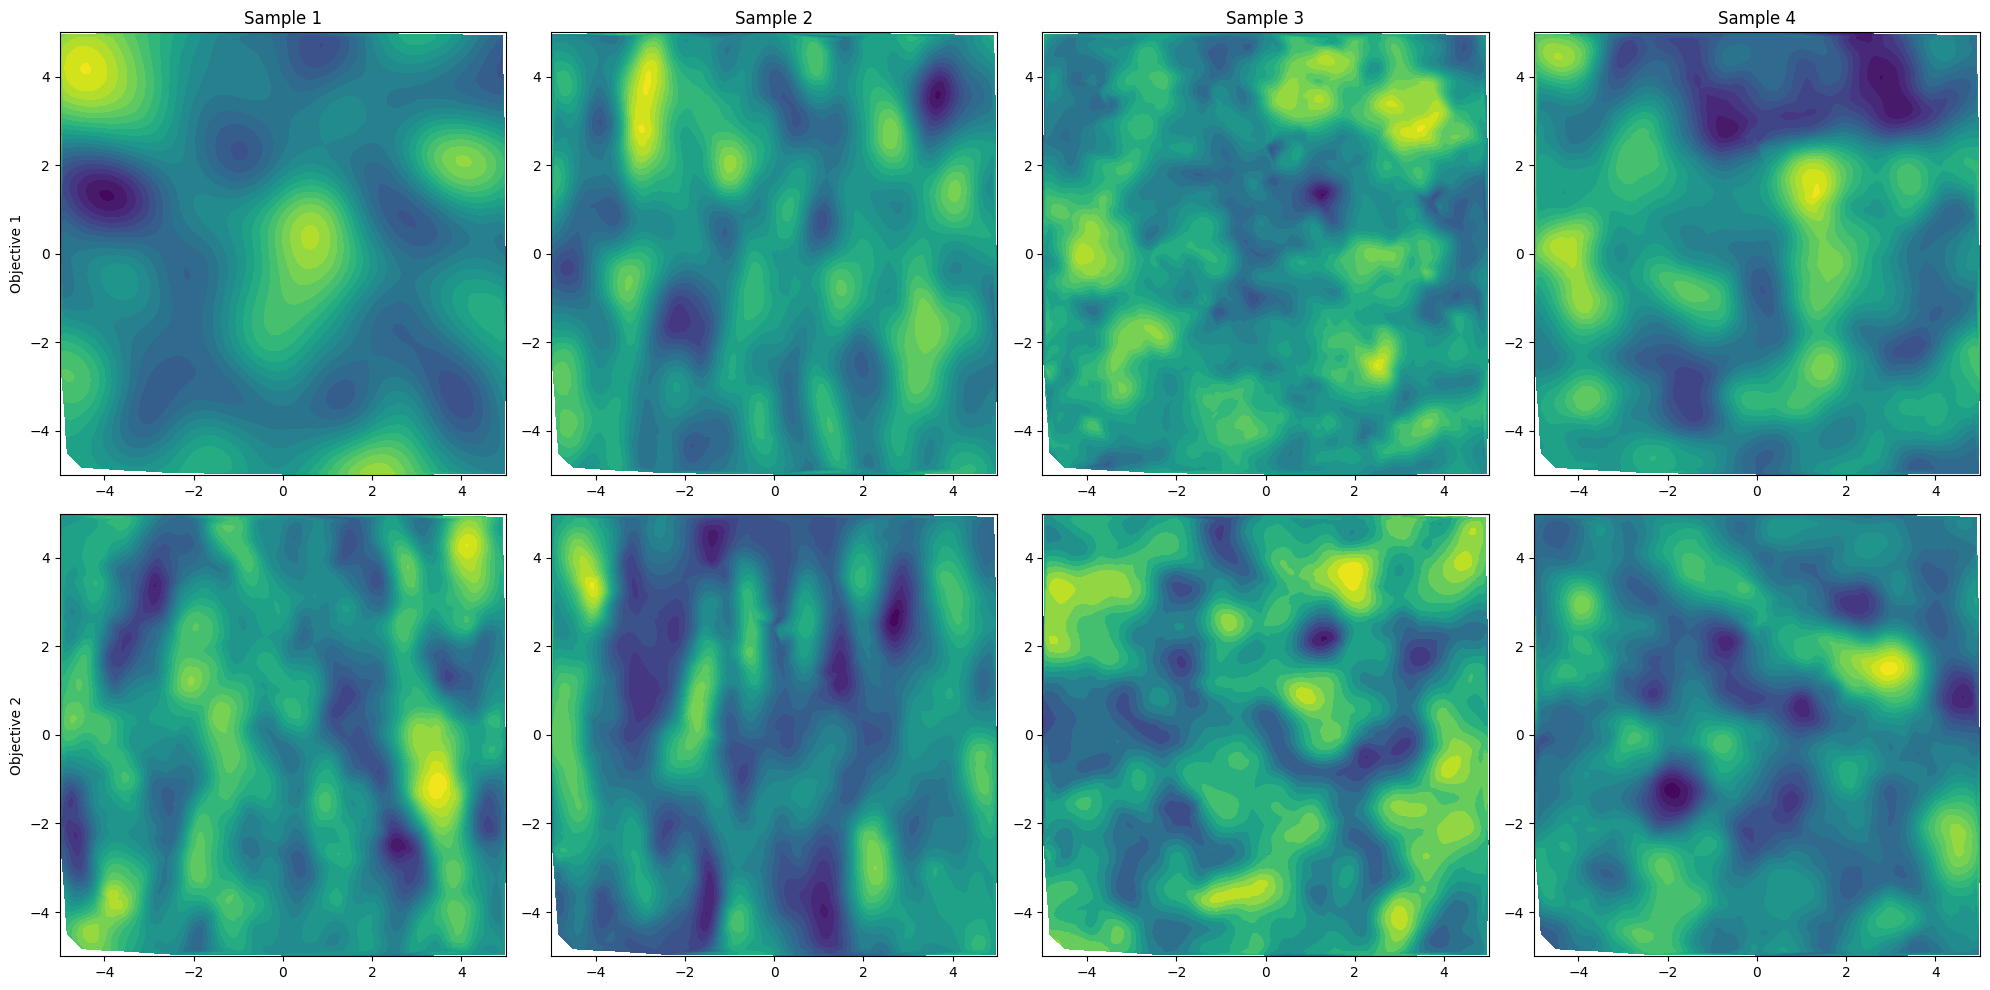

In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))
os.chdir(os.path.abspath(".."))

import torch
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

from data.dataset import MultiFileHDF5Dataset, get_datapaths

%reload_ext autoreload
%autoreload 2

x_dim = 2
y_dim = 2
data_id = None
mode = "test"

# Load dataset
datapaths = get_datapaths(
    mode=mode,
    data_id=data_id,
    x_dim_list=[x_dim],
    y_dim_list=[y_dim],
)
dataset = MultiFileHDF5Dataset(
    file_paths=datapaths,
    max_x_dim=x_dim,
    max_y_dim=y_dim,
    standardize=True,
    range_scale=[-1, 1],
)

color_map = plt.get_cmap("viridis")
grid_res = 1000
fig, axes = plt.subplots(y_dim, 4, figsize=(20, 5 * y_dim))
axes = axes.ravel()

for s in range(4):
    x, y, _, _ = dataset[s]
    x = torch.from_numpy(x).to(torch.float32)
    y = torch.from_numpy(y).to(torch.float32)

    # intepolate
    xi = np.linspace(-5.0, 5.0, grid_res, endpoint=True)
    xj = np.linspace(-5.0, 5.0, grid_res, endpoint=True)
    xi_grid, xj_grid = np.meshgrid(xi, xj)

    for i in range(y_dim):
        ax = axes[i * 4 + s]
        if i == 0:
            ax.set_title(f"Sample {s+1}")
        if s == 0:
            ax.set_ylabel(f"Objective {i+1}")
        if i < y_dim:
            y_grid = griddata(
                x.numpy(),
                y[:, i].numpy(),
                (xi_grid, xj_grid),
                method="cubic",
            )
            ax.contourf(xi_grid, xj_grid, y_grid, levels=20, cmap=color_map)
        else:
            ax.axis("off")

plt.xlim(-5.0, 5.0)
plt.tight_layout()
plt.show()